# Prepare station for CN3S

Assign cobacia and save the upstream basin and metadata with both drainage areas: `drainage_area` from Hidro `AreaDrenagem` and `drainage_area_geo` from geographic `nuareamont` (both in km²). Pass the parent stations directory to `prepare_station()`; Station creates the code-named subfolder.


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import geopandas as gpd

from hydro.station import Station
from hydrography import Hydrography
from utils.sql_connector import SqlConnector

## Configuration

Adjust these paths for your data mount. Both network files must describe the same hydrography. Preparation overwrites `metadata.json` and `upstream_watershed.parquet` for this station.


In [2]:
STATION_CODE = 29050000
DATA_FOLDER = Path("/data/CN3S/stations")

HYDROGRAPHY_DIR = Path("/data/Geospatial_BR_Data/Hidrografia/BHO_2017_5k")
WATERSHEDS_PATH = HYDROGRAPHY_DIR / "geoft_bho_2017_5k_area_drenagem.parquet"
REACHES_PATH = HYDROGRAPHY_DIR / "geoft_bho_2017_5k_trecho_drenagem.parquet"

## Station inventory

Connect to the station database. Assignment expects numeric `Latitude` and `Longitude` in decimal degrees (EPSG:4326), matching the local ANA inventory snapshot. Verify these fields before preparing a different inventory source. Series are loaded separately with `station.load_series(start=..., end=...)`.


In [3]:
conn = SqlConnector()

To sign in, use a web browser to open the page https://login.microsoft.com/device and enter the code E8PENNKBS to authenticate.


In [4]:
hydrography = Hydrography(watersheds_path=WATERSHEDS_PATH, reaches_path=REACHES_PATH)

In [5]:
station = Station(STATION_CODE, connector=conn)
station.info

,RegistroID,Descricao,Importado,Temporario,Removido,ImportadoRepetido,BaciaCodigo,SubBaciaCodigo,RioCodigo,EstadoCodigo,...,TipoRedeEstrategica,TipoRedeCaptacao,TipoRedeSedimentos,TipoRedeQualAgua,TipoRedeClasseVazao,UltimaAtualizacao,Operando,DataIns,DataAlt,geom_wkb
0,3730806.0,TELEMÉTRICA - VAISALA_GOES\r\nRHNR2017\r\nPCD_...,0,0,0,0,2,29,20001000,5,...,1,7,1,3,1,2026-03-31,1,None,2026-03-31,b'\x01\x01\x00\x00\x00\xab\xcf\xd5V\xec\x8fH\x...


In [6]:
metadata = station.prepare_station(hydrography, output_dir=DATA_FOLDER)
display(metadata)
print(station.metadata_path)
print(station.upstream_watershed_path)

{'station_code': '29050000',
 'station_name': 'MARABÁ',
 'cobacia': '63911',
 'drainage_area': 703000.0,
 'drainage_area_geo': 696359.0281876093}

/data/CN3S/stations/29050000/metadata.json
/data/CN3S/stations/29050000/upstream_watershed.parquet


## Inspect basin and station location


Text(0.5, 1.0, '29050000 — MARABÁ')

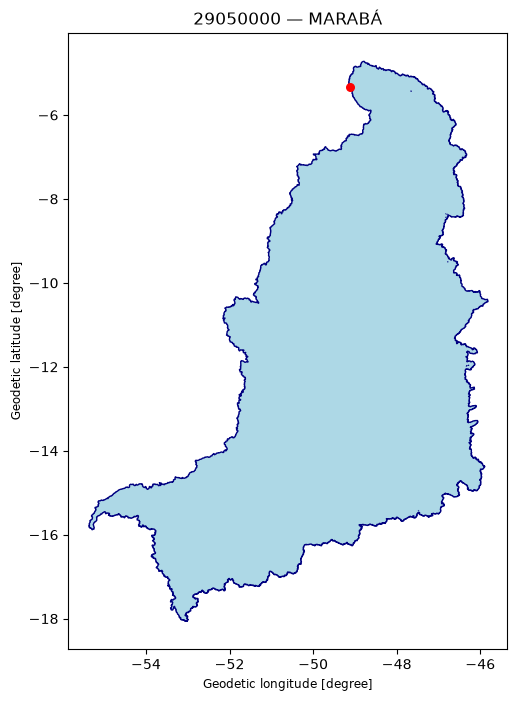

In [7]:
station_point = gpd.GeoSeries(
    gpd.points_from_xy(station.info["Longitude"], station.info["Latitude"]),
    crs="EPSG:4326",
).to_crs(station.upstream_watershed.crs)

ax = station.upstream_watershed.plot(facecolor="lightblue", edgecolor="navy", figsize=(8, 8))
station_point.plot(ax=ax, color="red", markersize=30)
ax.set_title(f"{station.code} — {station.name}")